## 1 ##

In [24]:
#importar librerias

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
lc = pd.read_csv('C:/Users/josel/Documents/zaza/LungCancer.csv')

In [6]:
print("Shape del dataset:", lc.shape)

Shape del dataset: (309, 16)


In [55]:
lc.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [7]:
print("\nTipos de datos:")
print(lc.dtypes)
print("\nValores nulos por columna:")
print(lc.isnull().sum())


Tipos de datos:
GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER              object
dtype: object

Valores nulos por columna:
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER             

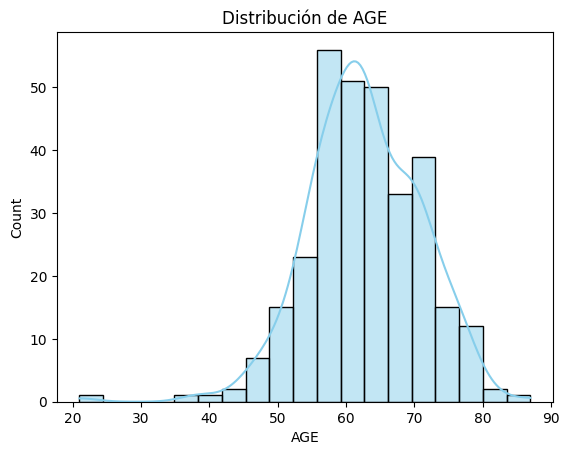

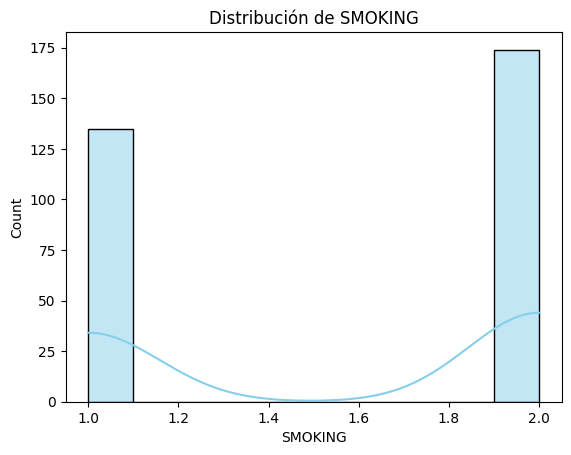

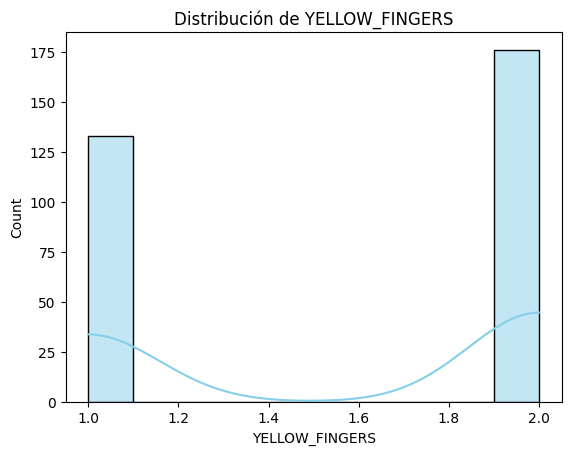

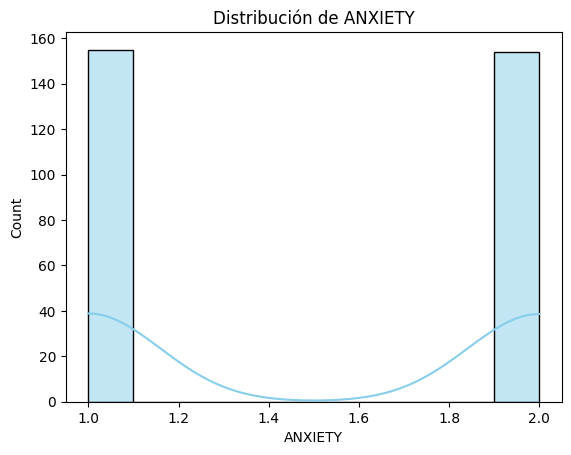

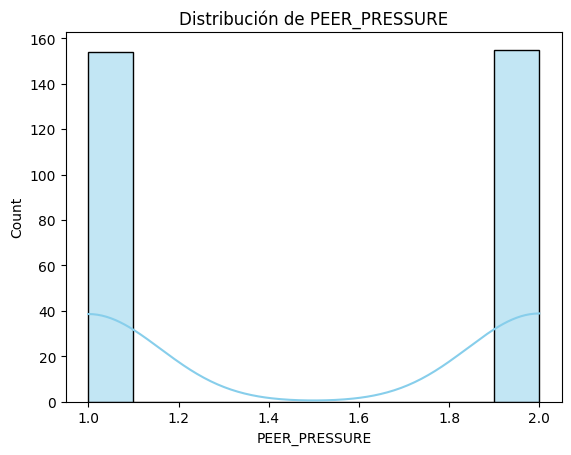

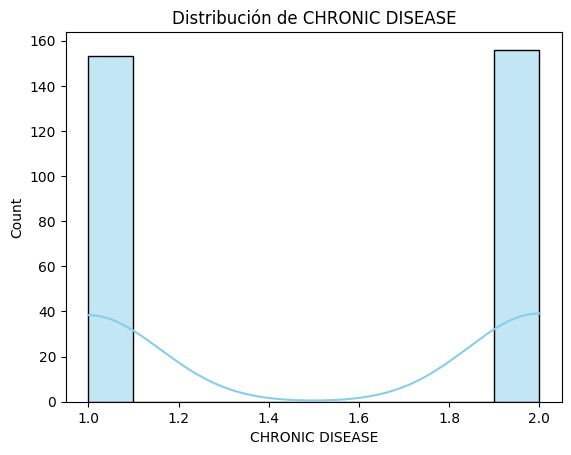

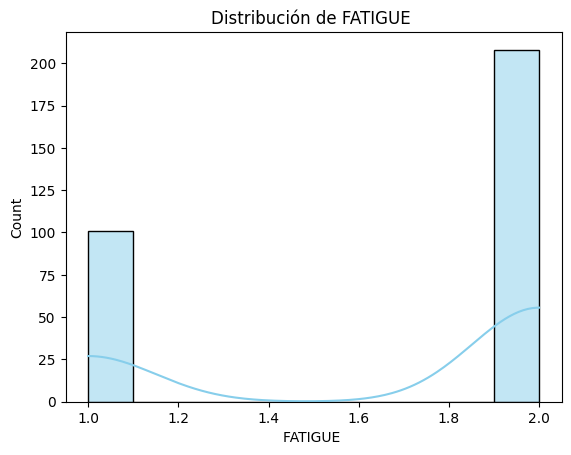

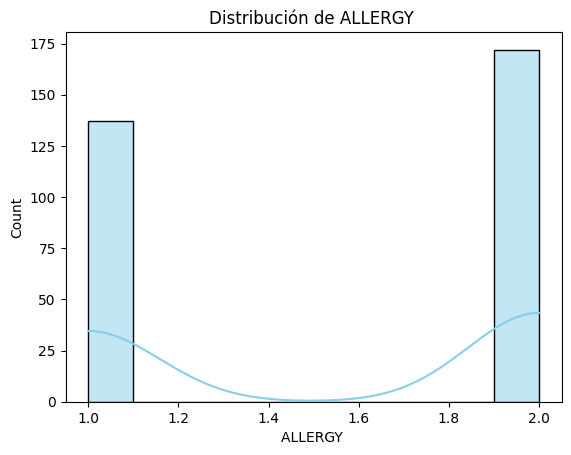

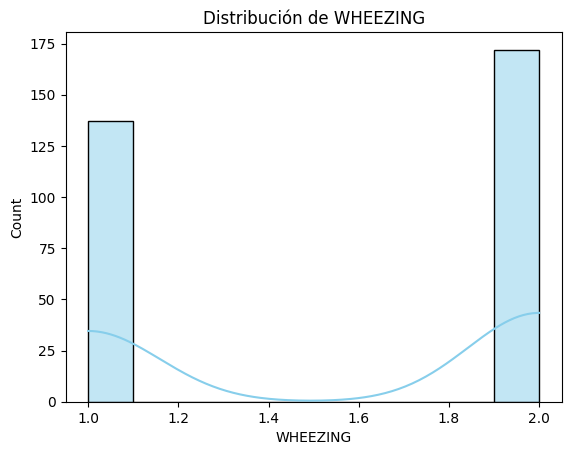

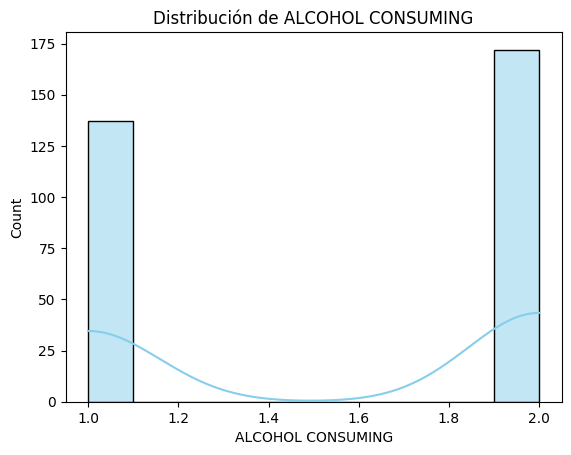

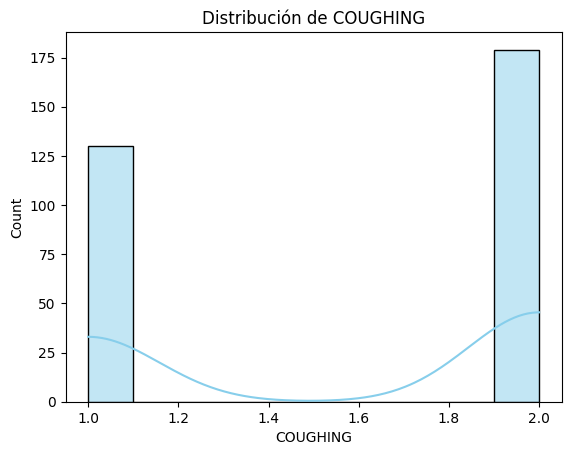

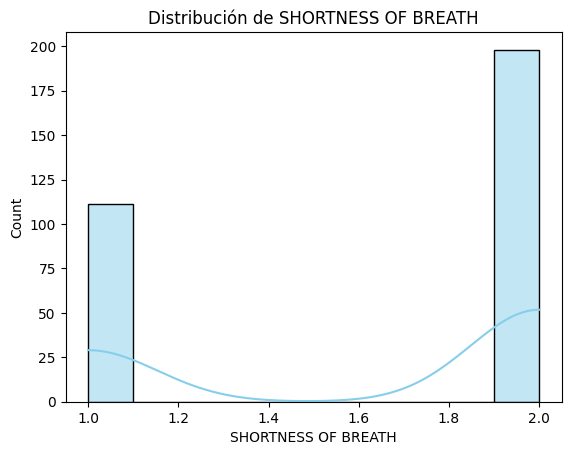

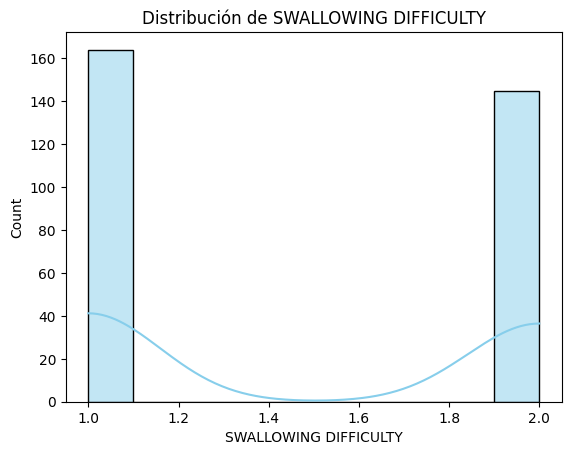

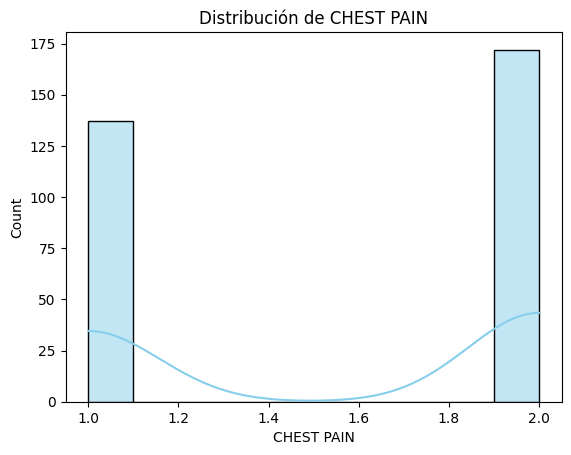

In [9]:
# Distribución de variables numéricas
num_cols = lc.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = lc.select_dtypes(include=['object', 'category']).columns.tolist()

for col in num_cols:
    plt.figure()
    sns.histplot(lc[col], kde=True, color='skyblue')
    plt.title(f"Distribución de {col}")
    plt.show()

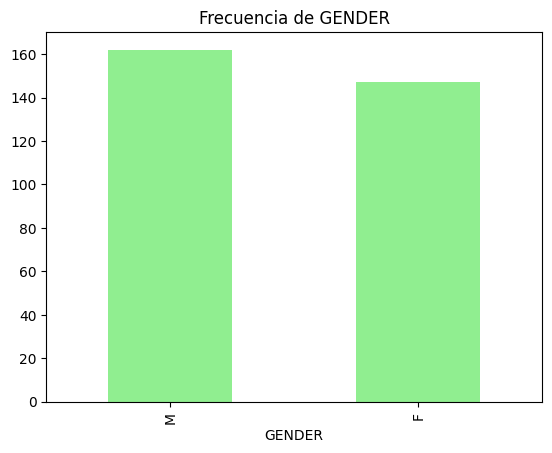

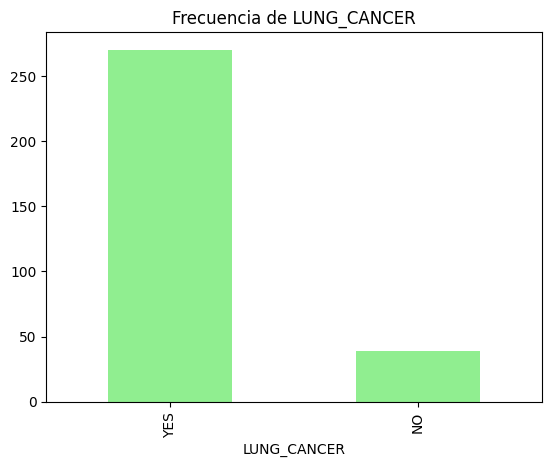

In [10]:
# Distribución de variables categóricas
for col in cat_cols:
    plt.figure()
    lc[col].value_counts().plot(kind='bar', color='lightgreen')
    plt.title(f"Frecuencia de {col}")
    plt.show()

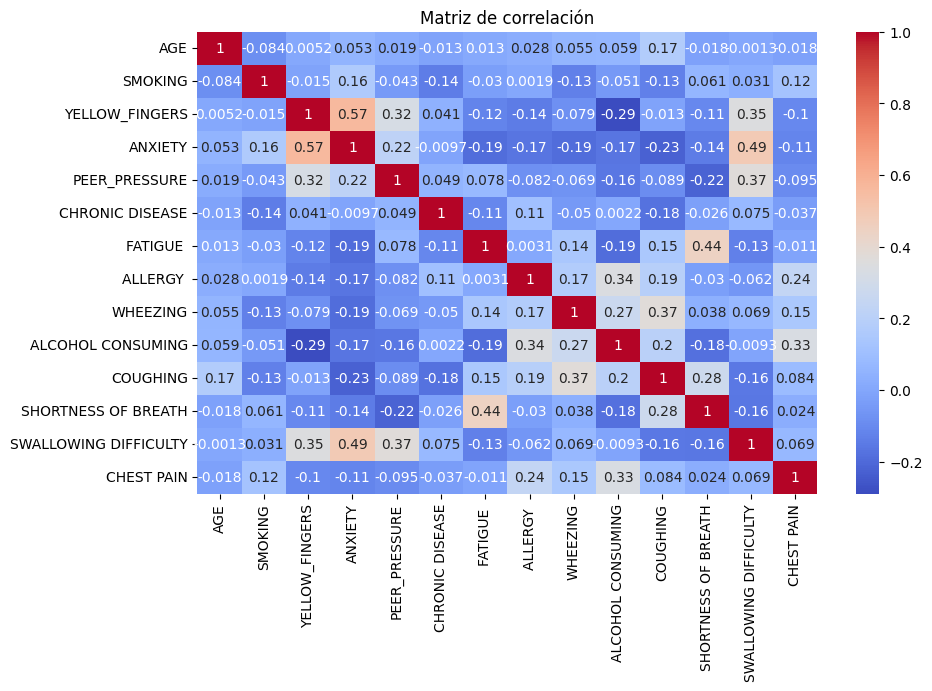

In [11]:
# Mapa de calor de correlaciones
plt.figure(figsize=(10,6))
sns.heatmap(lc.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## 2 ##

In [48]:
# Limpiar nombres de columnas (quita espacios al inicio y al final)
lc.columns = lc.columns.str.strip()


# Target y variables predictoras
target_col = 'LUNG_CANCER'
X = lc.drop(columns=[target_col])
y = lc[target_col]

# Convertir etiquetas a binario (0/1)
le = LabelEncoder()
y = le.fit_transform(y)

In [49]:
# Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocesadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [50]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (247, 15)
Tamaño prueba: (62, 15)


## 3 ##

In [52]:
# Limpieza y preparación de datos

# Quitar espacios en los nombres de columnas
lc.columns = lc.columns.str.strip()

# Definir columnas numéricas y categóricas
num_cols = ['AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
            'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
            'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
            'SWALLOWING DIFFICULTY', 'CHEST PAIN']

cat_cols = ['GENDER']

# Asegurar que las columnas numéricas sean de tipo numérico
lc[num_cols] = lc[num_cols].apply(pd.to_numeric, errors='coerce')

# Eliminar filas con valores nulos (por si hay datos faltantes)
lc.dropna(inplace=True)

# Separar variables independientes (X) y dependiente (y)
X = lc.drop(columns=['LUNG_CANCER'])
y = lc['LUNG_CANCER']

# Codificar la variable objetivo (Yes/No → 1/0)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# División en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocesamiento: escalado y codificación
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Regresión Logística': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Entrenamiento de modelos con pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

resultados = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    resultados[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred)
    }

# Mostrar resultados
import pandas as pd
pd.DataFrame(resultados).T


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.919355,0.945455,0.962963,0.954128,0.793981
KNN,0.887097,0.927273,0.944444,0.935780,0.722222
Random Forest,0.903226,0.944444,0.944444,0.944444,0.784722


In [53]:
# === 4. AJUSTE DE HIPERPARÁMETROS ===
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 5],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor),
                    ('model', RandomForestClassifier(random_state=42))]),
    param_grid,
    cv=4,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Mejores parámetros:", grid.best_params_)

best_model = grid.best_estimator_

Mejores parámetros: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [54]:
# === 5. EVALUACIÓN FINAL ===
final_pred = best_model.predict(X_test)
final_proba = best_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("ROC AUC:", roc_auc_score(y_test, final_proba))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, final_pred))

# Guardar modelo y preprocesador
import os
os.makedirs("lung_cancer_model_artifacts", exist_ok=True)
joblib.dump(best_model, "lung_cancer_model_artifacts/best_model_pipeline.joblib")
joblib.dump(preprocessor, "lung_cancer_model_artifacts/preprocessor.joblib")
print("\nModelo y preprocesador guardados en carpeta 'lung_cancer_model_artifacts'")

Accuracy: 0.9032258064516129
Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1: 0.9444444444444444
ROC AUC: 0.9513888888888888

Matriz de Confusión:
[[ 5  3]
 [ 3 51]]

Modelo y preprocesador guardados en carpeta 'lung_cancer_model_artifacts'


In [57]:
lc.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [58]:
lc["LUNG_CANCER"].unique()

array(['YES', 'NO'], dtype=object)

In [59]:
lc["GENDER"].unique()

array(['M', 'F'], dtype=object)